In [1]:
from pathlib import Path

DATA_DIR = Path("data/raw/EuroSAT_RGB")
print(DATA_DIR.exists())
print([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

True
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [2]:
import pandas as pd

image_paths = []
labels = []

for class_name in sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()]):
    class_folder = DATA_DIR / class_name
    for img_path in class_folder.glob("*.jpg"):
        image_paths.append(str(img_path))
        labels.append(class_name)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 27000


,filepath,label
0,data\raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_1.jpg,AnnualCrop
1,data\raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_10.jpg,AnnualCrop
2,data\raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_100...,AnnualCrop
3,data\raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_100...,AnnualCrop
4,data\raw\EuroSAT_RGB\AnnualCrop\AnnualCrop_100...,AnnualCrop


In [3]:
class_counts = df["label"].value_counts().sort_index()
class_counts

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64

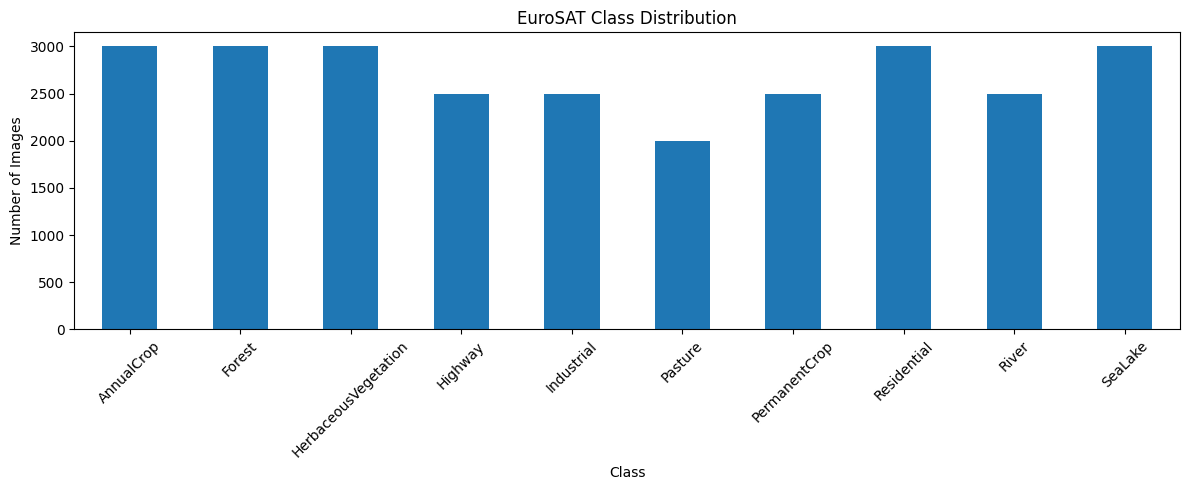

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("EuroSAT Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

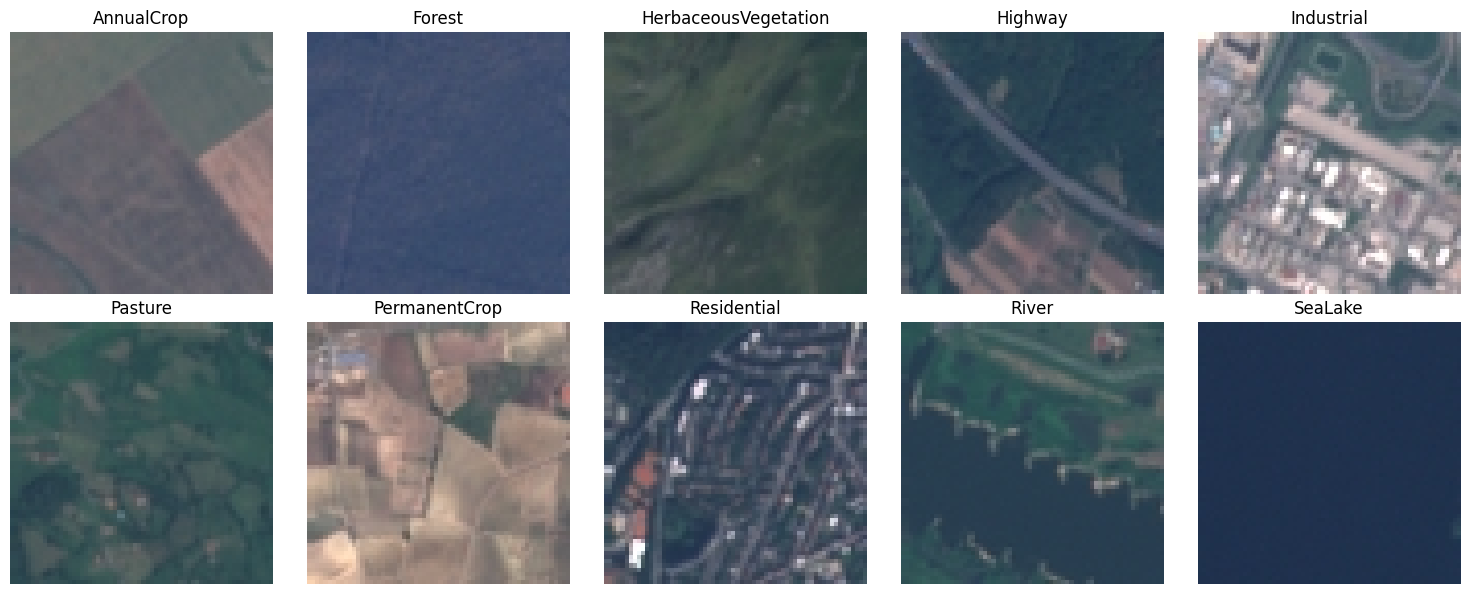

In [5]:
from PIL import Image
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for ax, class_name in zip(axes, class_counts.index):
    sample_path = df[df["label"] == class_name]["filepath"].sample(1).iloc[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

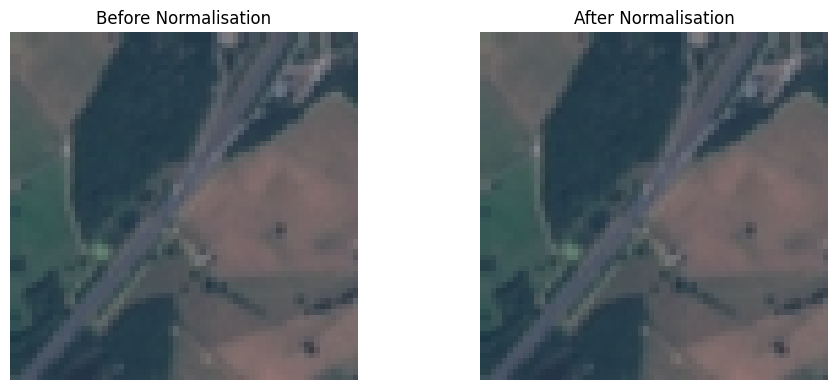

Original range: 29 to 143
Normalised range: 0.11372549019607843 to 0.5607843137254902


In [6]:
import numpy as np

sample_path = df["filepath"].sample(1).iloc[0]
img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

img_normalized = img_array / 255.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_array)
axes[0].set_title("Before Normalisation")
axes[0].axis("off")

axes[1].imshow(img_normalized)
axes[1].set_title("After Normalisation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Original range:", img_array.min(), "to", img_array.max())
print("Normalised range:", img_normalized.min(), "to", img_normalized.max())

In [7]:
from sklearn.model_selection import train_test_split

SEED = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 18900
Validation: 4050
Test: 4050


In [8]:
split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "val": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index()
})

split_counts

,train,val,test
label,,,
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375


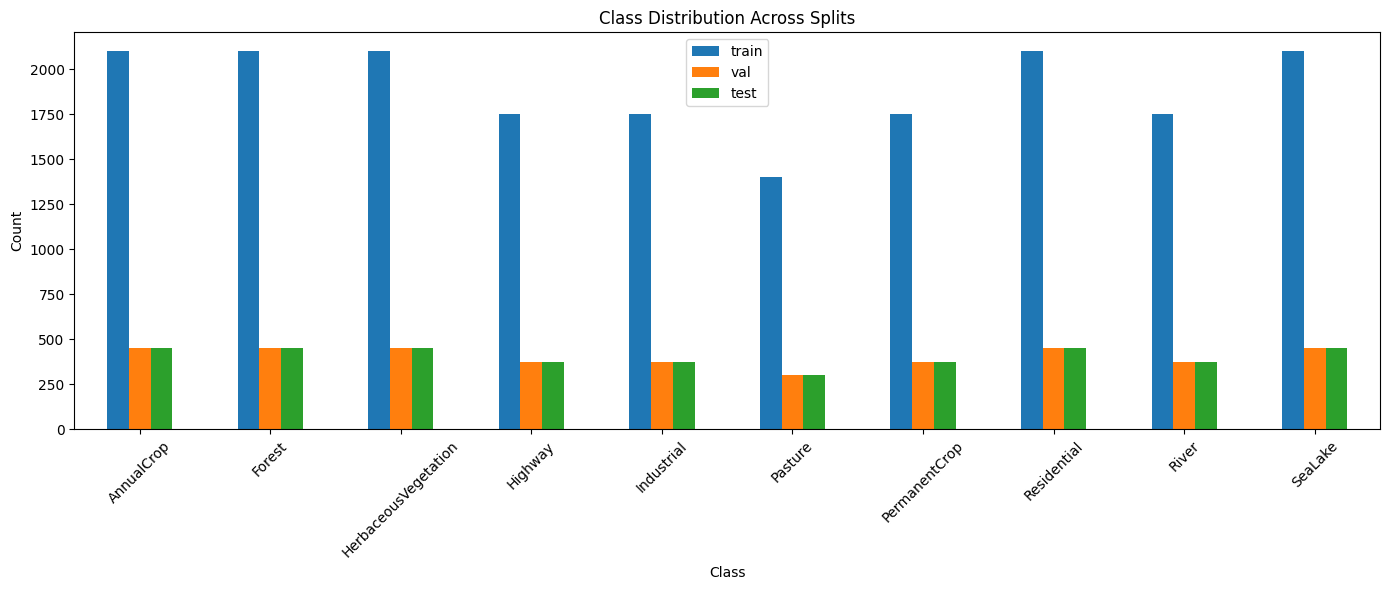

In [9]:
split_counts.plot(kind="bar", figsize=(14, 6))
plt.title("Class Distribution Across Splits")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

split_dir = Path("data/splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Splits saved.")